In [1]:
pip install praw pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [praw]
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the data
df = pd.read_csv('investments_PartI.csv', encoding='latin1')

# First look
print(df.shape)
df.head()

(54294, 39)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print(df.columns.tolist())

['permalink', 'name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [7]:
# Fix the column names by stripping extra spaces
df.columns = df.columns.str.strip()

# Confirm it worked
print(df.columns.tolist())

['permalink', 'name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [8]:
# Keep only the columns we need
cols_needed = [
    'name',
    'market',
    'funding_total_usd',
    'funding_rounds',
    'founded_year',
    'country_code',
    'status'
]

df_clean = df[cols_needed].copy()

# Drop rows where any of our key numeric features are missing
df_clean = df_clean.dropna(subset=['funding_total_usd', 'funding_rounds', 'founded_year'])

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"Rows after cleaning: {len(df_clean)}")
df_clean.head(10)

Rows after cleaning: 38482


,name,market,funding_total_usd,funding_rounds,founded_year,country_code,status
0,#waywire,News,"17,50,000",1.0,2012.0,USA,acquired
1,'Rock' Your Paper,Publishing,"40,000",1.0,2012.0,EST,operating
2,(In)Touch Network,Electronics,"15,00,000",1.0,2011.0,GBR,operating
3,-R- Ranch and Mine,Tourism,"60,000",2.0,2014.0,USA,operating
4,.Club Domains,Software,"70,00,000",1.0,2011.0,USA,NaN
5,0-6.com,Curated Web,"20,00,000",1.0,2007.0,NaN,operating
6,004 Technologies,Software,-,1.0,2010.0,USA,operating
7,"1,2,3 Listo",E-Commerce,"40,000",1.0,2012.0,CHL,operating
8,1-800-DENTIST,Health and Wellness,-,1.0,1986.0,USA,operating
9,1-800-DOCTORS,Health and Wellness,"17,50,000",1.0,1984.0,USA,operating


In [9]:
df_clean[['funding_total_usd', 'funding_rounds', 'founded_year']].describe()

,funding_rounds,founded_year
count,38482.000000,38482.000000
mean,1.793644,2007.359129
std,1.378088,7.579203
min,1.000000,1902.000000
25%,1.000000,2006.000000
50%,1.000000,2010.000000
75%,2.000000,2012.000000
max,18.000000,2014.000000


In [10]:
print(df_clean['funding_total_usd'].describe())
print("\nSample of very high funding:")
print(df_clean['funding_total_usd'].sort_values(ascending=False).head(10))

count     38482
unique    11919
top        -   
freq       6347
Name: funding_total_usd, dtype: object

Sample of very high funding:
3496      99,99,999 
7396      99,90,000 
25814     99,81,363 
33962     99,80,000 
11417        99,627 
11087     99,57,650 
28916     99,52,199 
8389      99,50,002 
15046     99,50,000 
9634      99,50,000 
Name: funding_total_usd, dtype: object


In [11]:
# Convert funding to numeric just in case
df_clean['funding_total_usd'] = pd.to_numeric(df_clean['funding_total_usd'], errors='coerce')

# Filter to reasonable modern startups:
# - Founded 1990 or later
# - Funding between $10,000 and $1 billion (removes noise at both ends)
df_clean = df_clean[
    (df_clean['founded_year'] >= 1990) &
    (df_clean['funding_total_usd'] >= 10_000) &
    (df_clean['funding_total_usd'] <= 1_000_000_000)
]

# Add a useful feature: company age (how old when data was collected, ~2015)
df_clean['company_age'] = 2015 - df_clean['founded_year']

df_clean = df_clean.reset_index(drop=True)
print(f"Rows after filtering: {len(df_clean)}")
df_clean[['funding_total_usd', 'funding_rounds', 'company_age']].describe()

Rows after filtering: 0


,funding_total_usd,funding_rounds,company_age
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [12]:
# Reload clean starting point
cols_needed = ['name', 'market', 'funding_total_usd', 'funding_rounds', 'founded_year', 'country_code', 'status']
df_clean = df[cols_needed].copy()

# Strip commas and spaces from funding column, then convert to numeric
df_clean['funding_total_usd'] = df_clean['funding_total_usd'].astype(str).str.replace(',', '').str.strip()
df_clean['funding_total_usd'] = pd.to_numeric(df_clean['funding_total_usd'], errors='coerce')

# Convert other columns too just to be safe
df_clean['funding_rounds'] = pd.to_numeric(df_clean['funding_rounds'], errors='coerce')
df_clean['founded_year'] = pd.to_numeric(df_clean['founded_year'], errors='coerce')

# Drop rows with missing values in key columns
df_clean = df_clean.dropna(subset=['funding_total_usd', 'funding_rounds', 'founded_year'])

# Sanity check before filtering
print(f"Rows before filtering: {len(df_clean)}")
print(df_clean['funding_total_usd'].describe())

Rows before filtering: 32135
count    3.213500e+04
mean     1.662219e+07
std      1.850814e+08
min      1.400000e+01
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


In [13]:
# Filter to reasonable modern startups
df_clean = df_clean[
    (df_clean['founded_year'] >= 1990) &
    (df_clean['funding_total_usd'] >= 10_000) &
    (df_clean['funding_total_usd'] <= 1_000_000_000)
]

# Add company age feature
df_clean['company_age'] = 2015 - df_clean['founded_year']

df_clean = df_clean.reset_index(drop=True)
print(f"Rows after filtering: {len(df_clean)}")
df_clean[['funding_total_usd', 'funding_rounds', 'company_age']].describe()

Rows after filtering: 30993


,funding_total_usd,funding_rounds,company_age
count,3.099300e+04,30993.000000,30993.000000
mean,1.364838e+07,1.950215,7.002936
std,4.224895e+07,1.464211,4.787160
min,1.000000e+04,1.000000,1.000000
25%,3.529570e+05,1.000000,3.000000
50%,2.000000e+06,1.000000,6.000000
75%,1.000000e+07,2.000000,9.000000
max,9.800000e+08,18.000000,25.000000


In [14]:
print(df_clean['status'].value_counts())

status
operating    26130
acquired      2531
closed        1615
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

# Select our three clustering features
features = ['funding_total_usd', 'funding_rounds', 'company_age']
X = df_clean[features].copy()

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done! Sample of scaled values:")
print(X_scaled[:5])

Scaling done! Sample of scaled values:
[[-0.28162995 -0.64897059 -0.83619522]
 [-0.32210498 -0.64897059 -0.83619522]
 [-0.28754735 -0.64897059 -0.62729975]
 [-0.32163159  0.03400209 -1.25398616]
 [-0.15736451 -0.64897059 -0.62729975]]


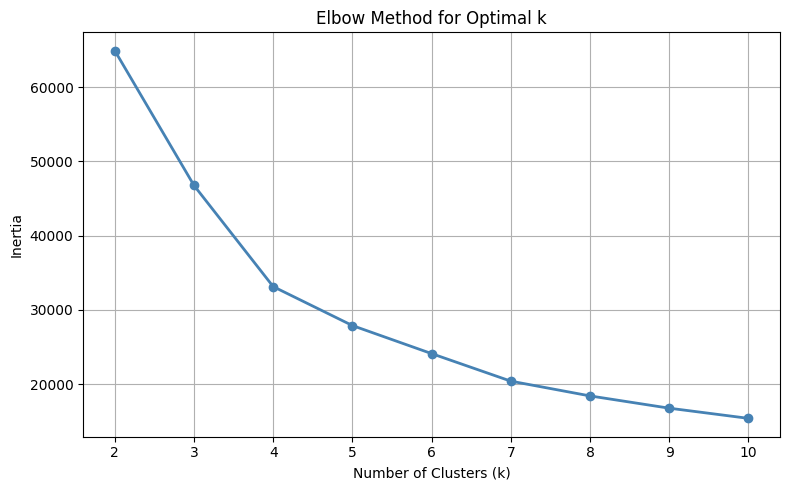

Elbow plot saved!


In [16]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print("Elbow plot saved!")

In [17]:
# Fit K-Means with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = km.fit_predict(X_scaled)

# Check how many startups landed in each cluster
print(df_clean['cluster'].value_counts().sort_index())


cluster
0    20695
1     6175
2      276
3     3847
Name: count, dtype: int64


In [18]:
# Look at the average characteristics of each cluster
cluster_profile = df_clean.groupby('cluster')[['funding_total_usd', 'funding_rounds', 'company_age']].mean()
cluster_profile['funding_total_usd'] = cluster_profile['funding_total_usd'].round(0)
cluster_profile['funding_rounds'] = cluster_profile['funding_rounds'].round(2)
cluster_profile['company_age'] = cluster_profile['company_age'].round(2)
print(cluster_profile)

         funding_total_usd  funding_rounds  company_age
cluster                                                
0                3925577.0            1.48         4.52
1               14628465.0            1.56        14.33
2              352821687.0            4.48        10.50
3               40045445.0            4.90         8.34


In [19]:
# See what % of each cluster is acquired, operating, closed
status_dist = df_clean.groupby(['cluster', 'status']).size().unstack(fill_value=0)
status_pct = status_dist.div(status_dist.sum(axis=1), axis=0).round(3) * 100
print(status_pct)

status   acquired  closed  operating
cluster                             
0             5.0     5.8       89.1
1            17.3     5.7       77.0
2             9.9     1.1       89.0
3            11.8     2.4       85.8


In [20]:
# Find 3 example companies per cluster
for c in range(4):
    print(f"\n--- Cluster {c} examples ---")
    sample = df_clean[df_clean['cluster'] == c][['name', 'market', 'funding_total_usd', 'funding_rounds', 'company_age', 'status']].sample(5, random_state=42)
    print(sample.to_string())


--- Cluster 0 examples ---
                               name                    market  funding_total_usd  funding_rounds  company_age     status
22271                       REscour   Commercial Real Estate            100000.0             1.0          2.0  operating
23901                   Shopventory                  Finance           2030000.0             3.0          2.0  operating
13182  Intimate Bridge 2 Conception            Manufacturing           4775000.0             2.0          6.0  operating
19667                         Parko            Crowdsourcing           1100000.0             1.0          4.0  operating
5101              CHiWAO Mobile App                 Software           2100000.0             1.0          4.0  operating

--- Cluster 1 examples ---
                         name                 market  funding_total_usd  funding_rounds  company_age     status
11525       Harbinger Medical           Health Care            550000.0             1.0         22.0     c

In [21]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_clean['cluster'], sample_size=5000, random_state=42)
print(f"Silhouette Score: {score:.4f}")
print("\nInterpretation:")
print("  > 0.5  = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2  = weak clusters")

Silhouette Score: 0.5084

Interpretation:
  > 0.5  = strong clusters
  0.2-0.5 = reasonable clusters
  < 0.2  = weak clusters


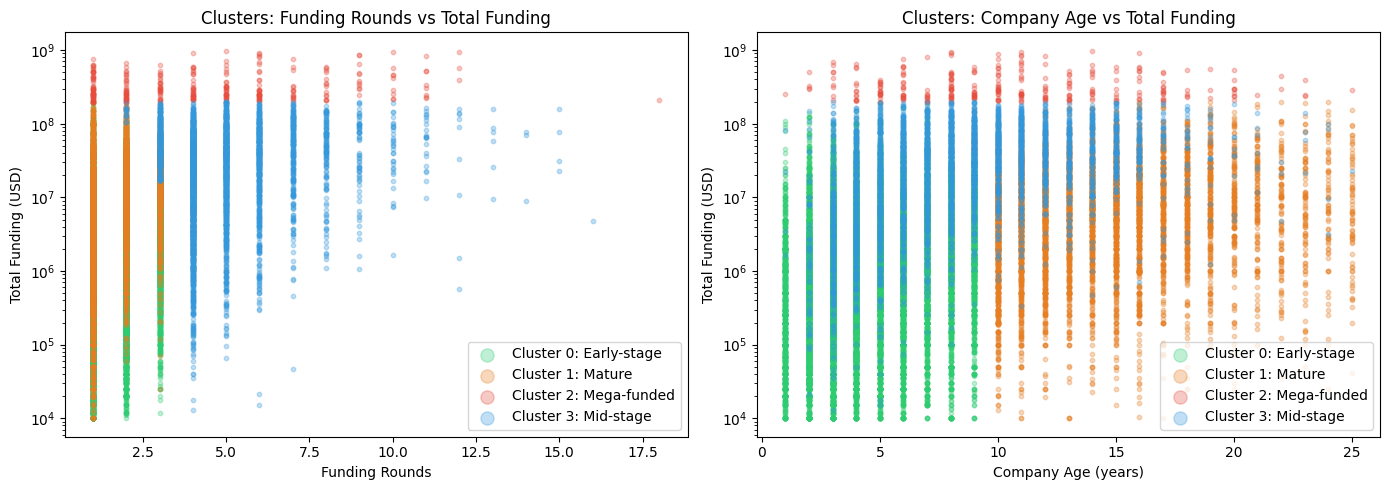

Cluster plot saved!


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e67e22', '#e74c3c', '#3498db']
labels = ['Cluster 0: Early-stage', 'Cluster 1: Mature', 'Cluster 2: Mega-funded', 'Cluster 3: Mid-stage']

# Plot 1: Funding vs Rounds
for c in range(4):
    subset = df_clean[df_clean['cluster'] == c]
    axes[0].scatter(subset['funding_rounds'], subset['funding_total_usd'],
                    alpha=0.3, s=10, color=colors[c], label=labels[c])
axes[0].set_xlabel('Funding Rounds')
axes[0].set_ylabel('Total Funding (USD)')
axes[0].set_title('Clusters: Funding Rounds vs Total Funding')
axes[0].legend(markerscale=3)
axes[0].set_yscale('log')

# Plot 2: Age vs Funding
for c in range(4):
    subset = df_clean[df_clean['cluster'] == c]
    axes[1].scatter(subset['company_age'], subset['funding_total_usd'],
                    alpha=0.3, s=10, color=colors[c], label=labels[c])
axes[1].set_xlabel('Company Age (years)')
axes[1].set_ylabel('Total Funding (USD)')
axes[1].set_title('Clusters: Company Age vs Total Funding')
axes[1].legend(markerscale=3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('cluster_plot.png', dpi=150)
plt.show()
print("Cluster plot saved!")

In [23]:
# Final summary table for the post
summary = df_clean.groupby('cluster').agg(
    count=('name', 'count'),
    avg_funding=('funding_total_usd', 'mean'),
    avg_rounds=('funding_rounds', 'mean'),
    avg_age=('company_age', 'mean')
).round(2)

summary['label'] = ['Early-stage Seedlings', 'Mature Bootstrappers', 
                     'Mega-funded Giants', 'Mid-stage Growth']

print(summary)

         count   avg_funding  avg_rounds  avg_age                  label
cluster                                                                 
0        20694  3.925577e+06        1.48     4.52  Early-stage Seedlings
1         6175  1.462847e+07        1.56    14.33   Mature Bootstrappers
2          276  3.528217e+08        4.48    10.50     Mega-funded Giants
3         3847  4.004544e+07        4.90     8.34       Mid-stage Growth
